# What Lifestyle and Behavioral Habits Predict BMI in Young People?

**Research Question:** Can we predict Body Mass Index (BMI) from self-reported lifestyle habits and behavioral traits among young people? Which habits are the strongest predictors?

I use the Young People Survey (2013, Slovakia, n=1,010) to explore whether things like diet quality, physical activity, alcohol use, smoking, and some personality-related traits can predict BMI. I compare two regression models: Ordinary Least Squares (OLS) linear regression and Ridge regression with cross-validated regularisation. BMI is a continuous numeric variable so regression is the right approach here.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [2]:
import os

if os.path.exists('YPS.csv'):
    df = pd.read_csv('YPS.csv')
else:
    df = pd.read_csv('../YPS.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values total: {df.isnull().sum().sum()}")

Dataset loaded: 1010 rows, 150 columns
Missing values total: 608


## 2. Variable Selection and Data Preparation

In [3]:
# Compute BMI
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# Filter unrealistic BMI values
df = df[(df['BMI'] >= 14) & (df['BMI'] <= 50)].copy()
print(f"After BMI filter: {len(df)} rows")

# Encode categorical variables
smoking_map = {'never smoked': 0, 'tried smoking': 1, 'former smoker': 2, 'current smoker': 3}
alcohol_map = {'never': 0, 'social drinker': 1, 'drink a lot': 2}
gender_map = {'female': 0, 'male': 1}

df['Smoking_enc'] = df['Smoking'].map(smoking_map)
df['Alcohol_enc'] = df['Alcohol'].map(alcohol_map)
df['Gender_enc'] = df['Gender'].map(gender_map)

# Define predictors and target
feature_names = [
    'Healthy eating', 'Active sport', 'Passive sport',
    'Spending on healthy eating', 'Spending on gadgets',
    'Energy levels', 'Happiness in life', 'Age',
    'Smoking_enc', 'Alcohol_enc', 'Gender_enc',
    'Workaholism', 'Self-criticism'
]
target_name = 'BMI'

# Keep only needed columns and drop NAs
df_model = df[feature_names + [target_name]].dropna().copy()
print(f"Final modelling sample: {len(df_model)} rows, {len(feature_names)} predictors")

X = df_model[feature_names]
y = df_model[target_name]

print("\nDescriptive statistics:")
print(df_model.describe().round(2))

After BMI filter: 979 rows
Final modelling sample: 924 rows, 13 predictors

Descriptive statistics:
       Healthy eating  Active sport  Passive sport  \
count          924.00        924.00         924.00   
mean             3.03          3.28           3.38   
std              0.94          1.51           1.40   
min              1.00          1.00           1.00   
25%              3.00          2.00           2.00   
50%              3.00          3.00           3.00   
75%              4.00          5.00           5.00   
max              5.00          5.00           5.00   

       Spending on healthy eating  Spending on gadgets  Energy levels  \
count                      924.00               924.00         924.00   
mean                         3.55                 2.88           3.63   
std                          1.09                 1.28           1.00   
min                          1.00                 1.00           1.00   
25%                          3.00               

## 3. Exploratory Data Analysis

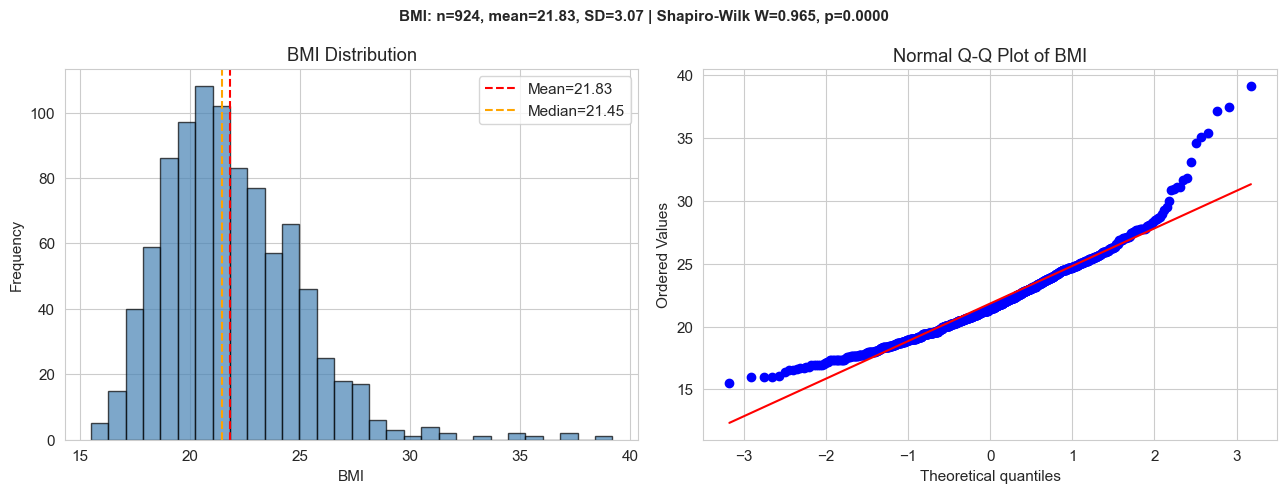

Shapiro-Wilk: W=0.9646, p=0.0000
Skewness=1.104, Kurtosis=2.963


In [4]:
# Figure 1: BMI distribution and Q-Q plot
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean={y.mean():.2f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median={y.median():.2f}')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BMI Distribution')
axes[0].legend()

probplot(y, plot=axes[1])
axes[1].set_title('Normal Q-Q Plot of BMI')

stat, p_sw = stats.shapiro(y.sample(min(500, len(y)), random_state=42))
plt.suptitle(f'BMI: n={len(y)}, mean={y.mean():.2f}, SD={y.std():.2f} | Shapiro-Wilk W={stat:.3f}, p={p_sw:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_bmi_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Shapiro-Wilk: W={stat:.4f}, p={p_sw:.4f}")
print(f"Skewness={y.skew():.3f}, Kurtosis={y.kurtosis():.3f}")

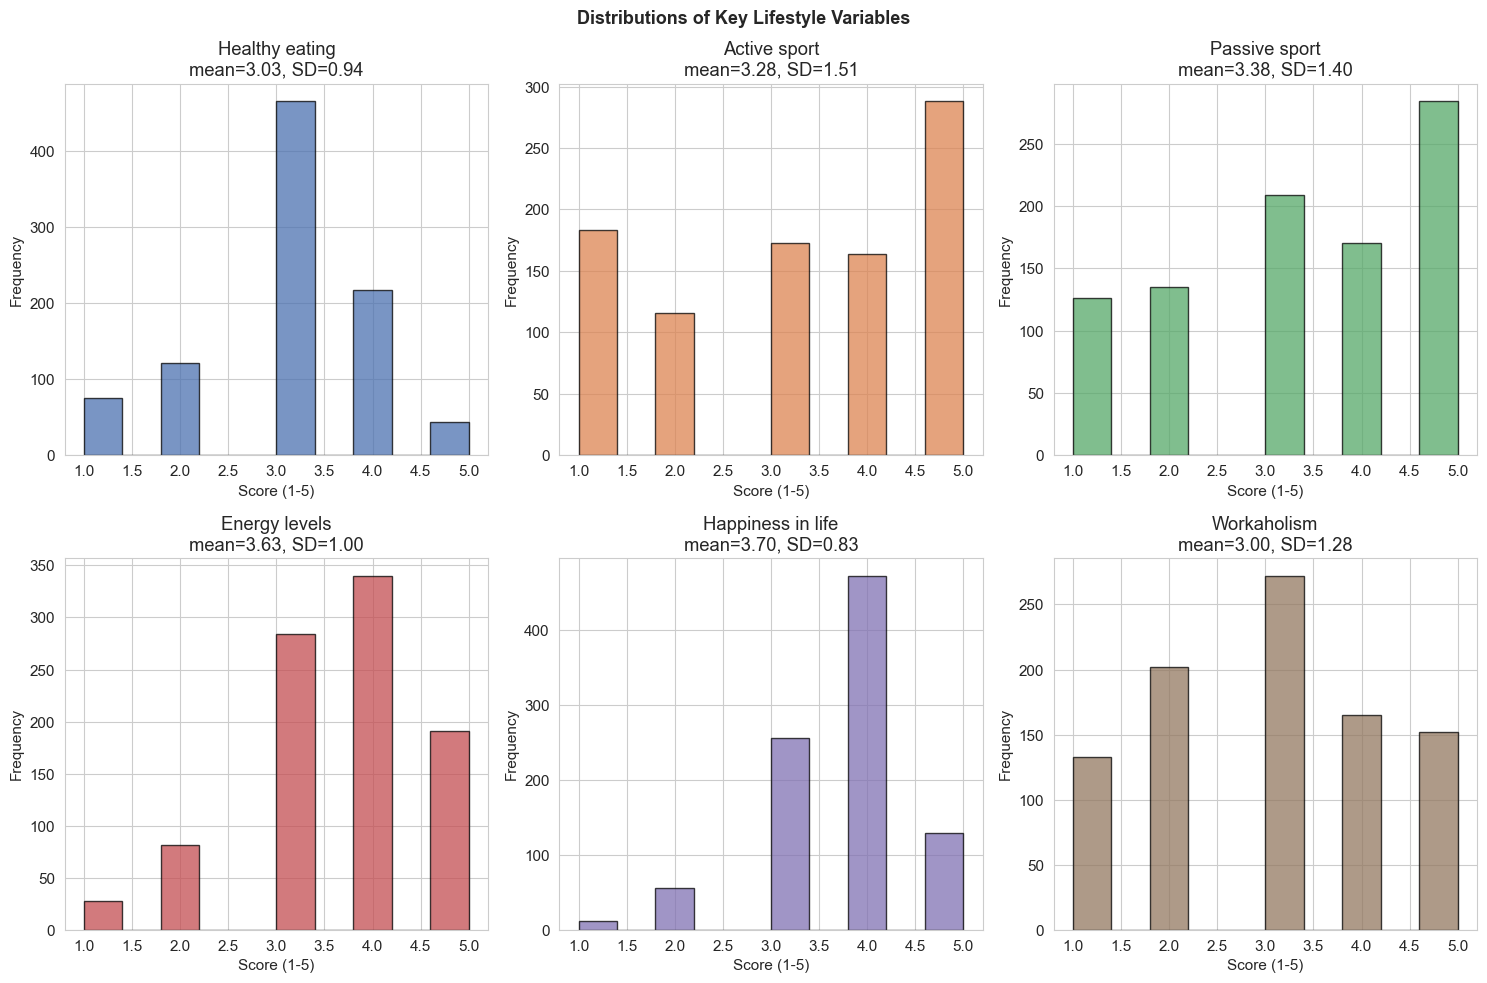

Saved: fig2_lifestyle_dist.png


In [5]:
# Figure 2: Key lifestyle predictor distributions
key_vars = ['Healthy eating', 'Active sport', 'Passive sport',
            'Energy levels', 'Happiness in life', 'Workaholism']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

for i, var in enumerate(key_vars):
    data = df_model[var].dropna()
    axes[i].hist(data, bins=10, edgecolor='black', color=colors[i], alpha=0.75)
    axes[i].set_title(f'{var}\nmean={data.mean():.2f}, SD={data.std():.2f}')
    axes[i].set_xlabel('Score (1-5)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distributions of Key Lifestyle Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_lifestyle_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_lifestyle_dist.png")

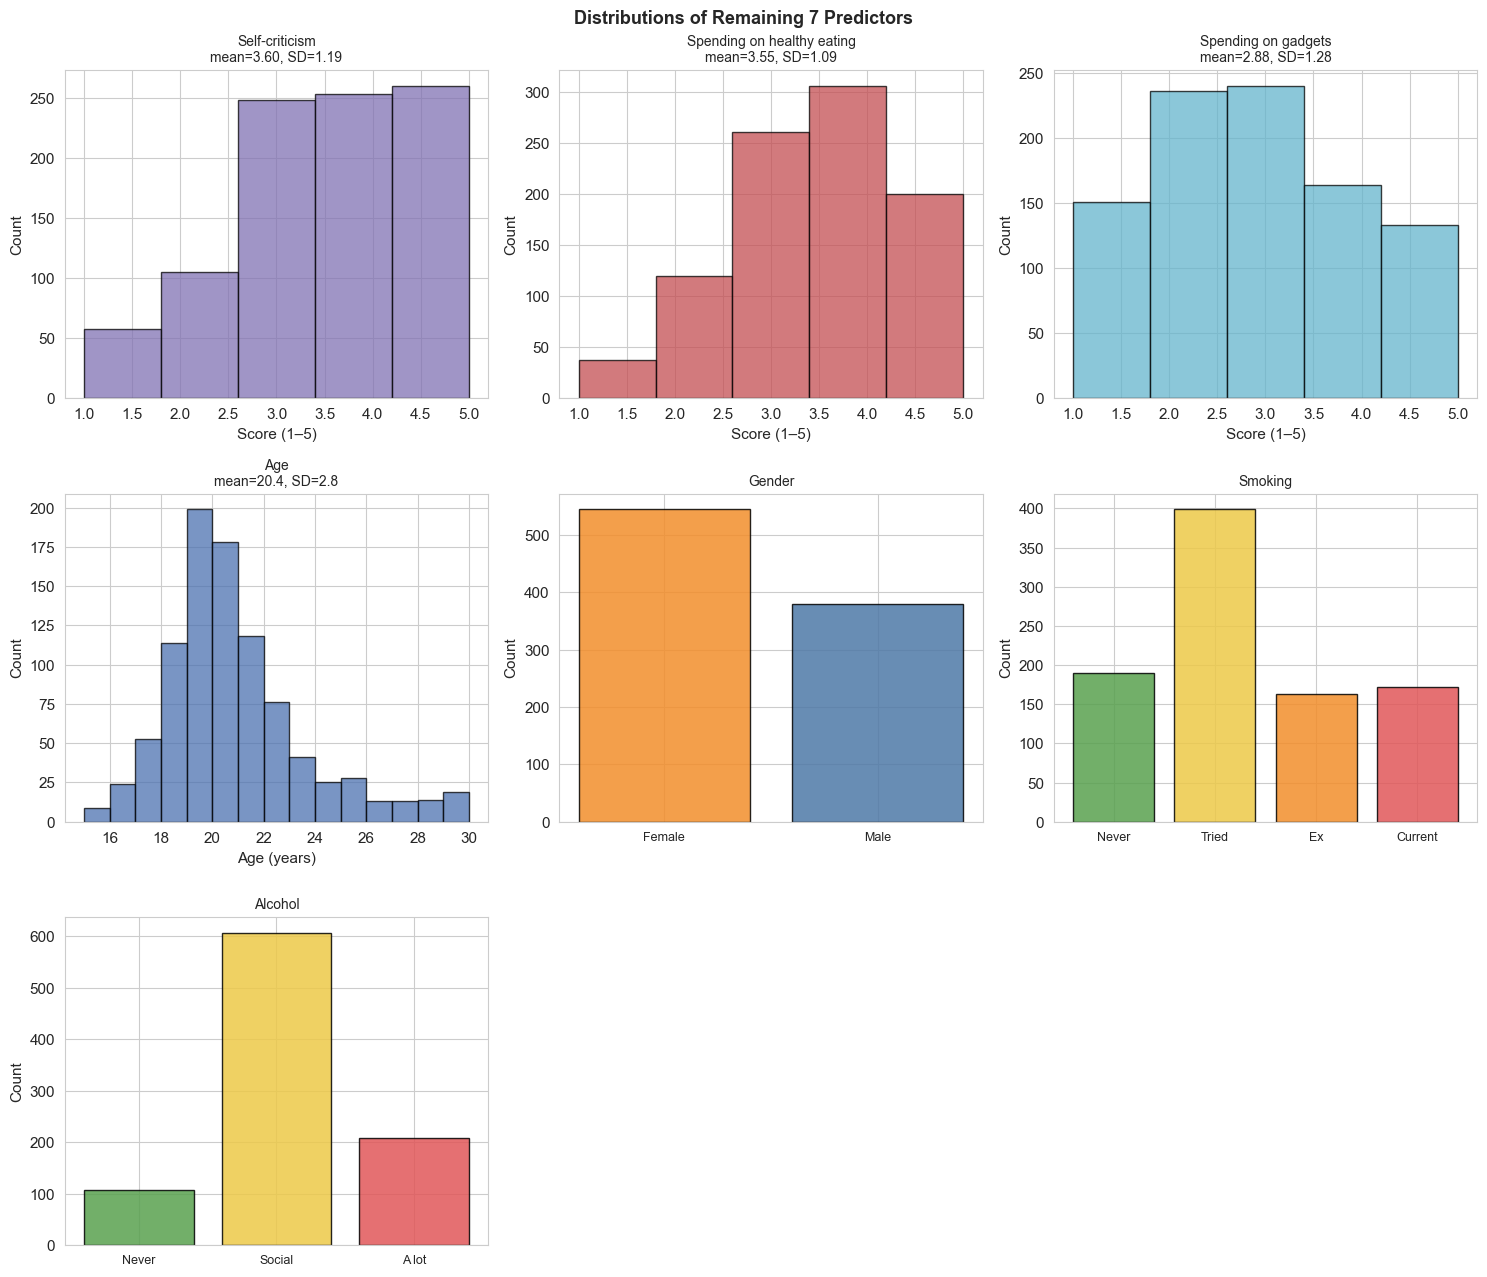

Saved: fig2b_remaining_predictors.png


In [6]:

# Figure 2b: Distributions of remaining 7 predictors not in Figure 2
# (Self-criticism, Spending on healthy eating, Spending on gadgets, Age,
#  Gender, Smoking, Alcohol)

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.ravel()

# --- Likert-scale continuous variables (histograms) ---
likert_remaining = ['Self-criticism', 'Spending on healthy eating', 'Spending on gadgets']
lik_colors = ['#8172B3', '#C44E52', '#64B5CD']
for i, (var, col) in enumerate(zip(likert_remaining, lik_colors)):
    data = df_model[var].dropna()
    axes[i].hist(data, bins=5, edgecolor='black', color=col, alpha=0.75)
    axes[i].set_title(f'{var}\nmean={data.mean():.2f}, SD={data.std():.2f}', fontsize=10)
    axes[i].set_xlabel('Score (1–5)')
    axes[i].set_ylabel('Count')

# --- Age: continuous histogram ---
data_age = df_model['Age'].dropna()
axes[3].hist(data_age, bins=15, edgecolor='black', color='#4C72B0', alpha=0.75)
axes[3].set_title(f'Age\nmean={data_age.mean():.1f}, SD={data_age.std():.1f}', fontsize=10)
axes[3].set_xlabel('Age (years)')
axes[3].set_ylabel('Count')

# --- Categorical variables: bar charts ---
cat_vars = [
    ('Gender_enc',  {0: 'Female', 1: 'Male'},         'Gender',   ['#F28E2B', '#4E79A7']),
    ('Smoking_enc', {0: 'Never', 1: 'Tried', 2: 'Ex', 3: 'Current'}, 'Smoking', ['#59A14F','#EDC948','#F28E2B','#E15759']),
    ('Alcohol_enc', {0: 'Never', 1: 'Social', 2: 'A lot'}, 'Alcohol', ['#59A14F','#EDC948','#E15759']),
]
for ax_idx, (col_name, labels_map, title, colors_cat) in zip([4, 5, 6], cat_vars):
    counts = df_model[col_name].map(labels_map).value_counts().reindex(labels_map.values())
    axes[ax_idx].bar(range(len(counts)), counts.values, color=colors_cat[:len(counts)],
                     edgecolor='black', alpha=0.85)
    axes[ax_idx].set_xticks(range(len(counts)))
    axes[ax_idx].set_xticklabels(counts.index, fontsize=9)
    axes[ax_idx].set_title(title, fontsize=10)
    axes[ax_idx].set_ylabel('Count')

# Turn off last 2 empty axes
axes[7].axis('off')
axes[8].axis('off')

plt.suptitle('Distributions of Remaining 7 Predictors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2b_remaining_predictors.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2b_remaining_predictors.png")


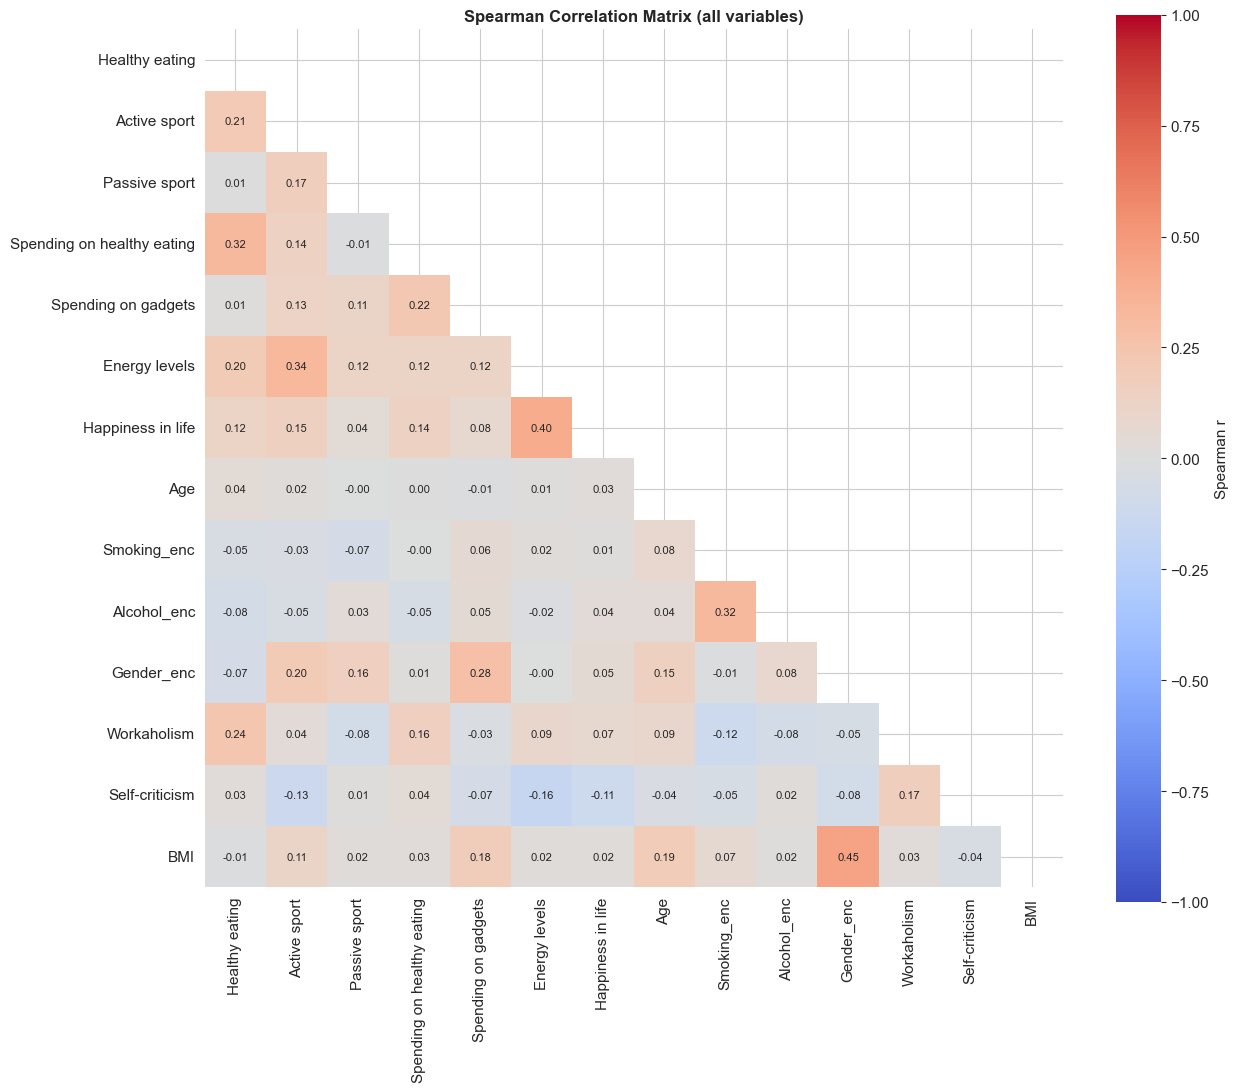

Top correlations with BMI:
Gender_enc                    0.446
Age                           0.191
Spending on gadgets           0.179
Active sport                  0.111
Smoking_enc                   0.069
Self-criticism               -0.041
Spending on healthy eating    0.031
Workaholism                   0.029
Passive sport                 0.023
Happiness in life             0.022
Energy levels                 0.017
Alcohol_enc                   0.015
Healthy eating               -0.010
Name: BMI, dtype: float64


In [7]:
# Figure 3: Spearman correlation heatmap
corr = df_model.corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Spearman r'}, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            xticklabels=corr.columns, yticklabels=corr.columns)
ax.set_title('Spearman Correlation Matrix (all variables)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top correlations with BMI:")
print(corr['BMI'].drop('BMI').sort_values(key=abs, ascending=False).round(3))

In [8]:
# Gender group comparisons using Mann-Whitney U
female_df = df_model[df_model['Gender_enc'] == 0]
male_df = df_model[df_model['Gender_enc'] == 1]
print(f"Female n={len(female_df)}, Male n={len(male_df)}")
print()
print(f"{'Variable':<30} {'Female mean':>12} {'Male mean':>12} {'U statistic':>12} {'p-value':>10}")
print("-" * 78)

compare_vars = ['BMI', 'Healthy eating', 'Active sport', 'Passive sport',
                'Energy levels', 'Alcohol_enc', 'Smoking_enc', 'Workaholism']
mw_results = {}
for v in compare_vars:
    f_vals = female_df[v].dropna()
    m_vals = male_df[v].dropna()
    u_stat, p_val = stats.mannwhitneyu(f_vals, m_vals, alternative='two-sided')
    mw_results[v] = {'female_mean': f_vals.mean(), 'male_mean': m_vals.mean(),
                     'U': u_stat, 'p': p_val}
    sig = '*' if p_val < 0.05 else ''
    print(f"{v:<30} {f_vals.mean():>12.3f} {m_vals.mean():>12.3f} {u_stat:>12.1f} {p_val:>10.4f} {sig}")

Female n=545, Male n=379

Variable                        Female mean    Male mean  U statistic    p-value
------------------------------------------------------------------------------
BMI                                  20.803       23.319      49244.5     0.0000 *
Healthy eating                        3.090        2.955     110738.0     0.0433 *
Active sport                          3.037        3.628      79566.5     0.0000 *
Passive sport                         3.196        3.644      83953.0     0.0000 *
Energy levels                         3.635        3.631     103627.5     0.9269 
Alcohol_enc                           1.073        1.161      95054.5     0.0140 *
Smoking_enc                           1.350        1.332     104460.5     0.7546 
Workaholism                           3.061        2.916     109470.0     0.1115 


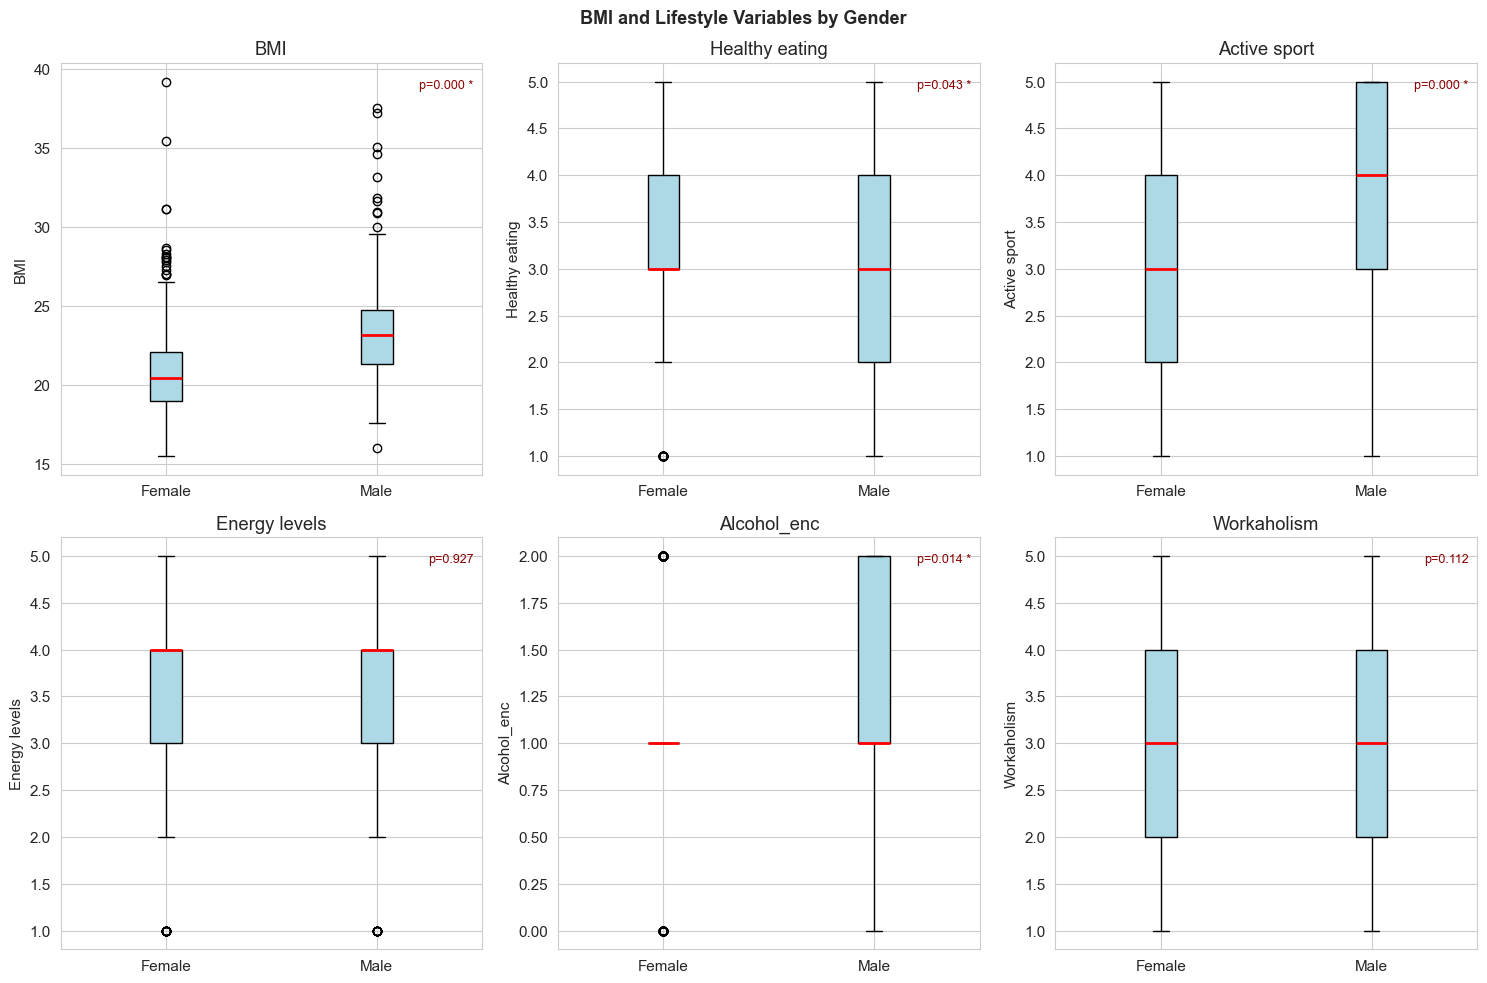

Saved: fig4_gender_bmi.png


In [9]:
# Figure 4: BMI and lifestyle variables by gender
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

boxplot_vars = ['BMI', 'Healthy eating', 'Active sport',
                'Energy levels', 'Alcohol_enc', 'Workaholism']
gender_labels = {0: 'Female', 1: 'Male'}

for i, var in enumerate(boxplot_vars):
    data_f = female_df[var].dropna()
    data_m = male_df[var].dropna()
    axes[i].boxplot([data_f, data_m], labels=['Female', 'Male'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)
    u_stat, p_val = stats.mannwhitneyu(data_f, data_m, alternative='two-sided')
    sig_text = f'p={p_val:.3f}' + (' *' if p_val < 0.05 else '')
    axes[i].text(0.98, 0.96, sig_text, transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='darkred')

plt.suptitle('BMI and Lifestyle Variables by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_gender_bmi.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_gender_bmi.png")

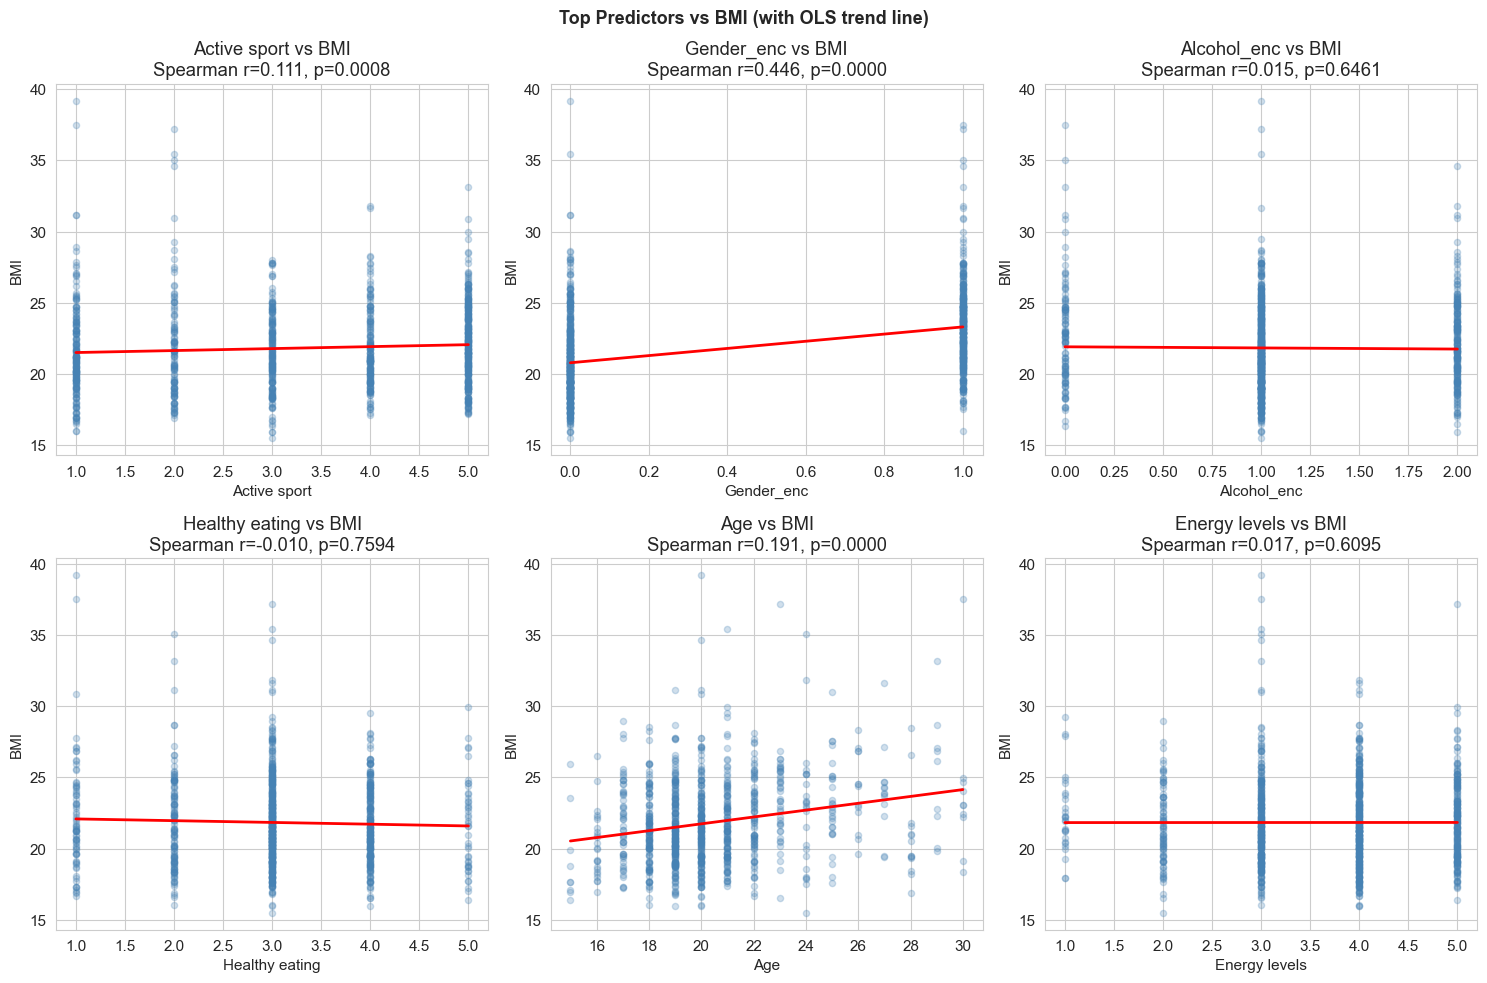

Saved: fig5_scatterplots.png


In [ ]:
# Figure 5: Scatter plots top 6 predictors vs BMI (with regression line)
scatter_vars = ['Active sport', 'Gender_enc', 'Alcohol_enc',
                'Healthy eating', 'Age', 'Energy levels']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(scatter_vars):
    x_var = df_model[var]
    axes[i].scatter(x_var, y, alpha=0.25, s=20, color='steelblue')
    m, b = np.polyfit(x_var, y, 1)
    x_line = np.linspace(x_var.min(), x_var.max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=2)
    r, p = stats.spearmanr(x_var, y)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('BMI')
    axes[i].set_title(f'{var} vs BMI\nSpearman r={r:.3f}, p={p:.4f}')

plt.suptitle('Top Predictors vs BMI (with OLS trend line)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5_scatterplots.png")

## 4. Preprocessing

In [11]:
# Standardise predictors (mean=0, SD=1) for fair coefficient comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=X.index)

print("Scaling complete.")
print(f"X shape: {X_scaled.shape},  y shape: {y.shape}")
print(f"\nScaled X means (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Scaled X stds  (should be ~1): {X_scaled.std(axis=0).round(4)}")

Scaling complete.
X shape: (924, 13),  y shape: (924,)

Scaled X means (should be ~0): [-0.  0.  0.  0.  0.  0. -0. -0.  0.  0.  0. -0.  0.]
Scaled X stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Model 1  Ordinary Least Squares Regression

In [12]:
# OLS regression with statsmodels (add constant for intercept)
X_ols = sm.add_constant(X_scaled_df)
ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

# Store key results
ols_r2 = ols_model.rsquared
ols_adj_r2 = ols_model.rsquared_adj
ols_aic = ols_model.aic
ols_bic = ols_model.bic
ols_fstat = ols_model.fvalue
ols_fpval = ols_model.f_pvalue
print(f"\nR²={ols_r2:.4f}, Adj R²={ols_adj_r2:.4f}, AIC={ols_aic:.2f}, BIC={ols_bic:.2f}")
print(f"F-statistic={ols_fstat:.4f}, p={ols_fpval:.6f}")

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     18.60
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           7.90e-39
Time:                        23:44:16   Log-Likelihood:                -2238.9
No. Observations:                 924   AIC:                             4506.
Df Residuals:                     910   BIC:                             4573.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

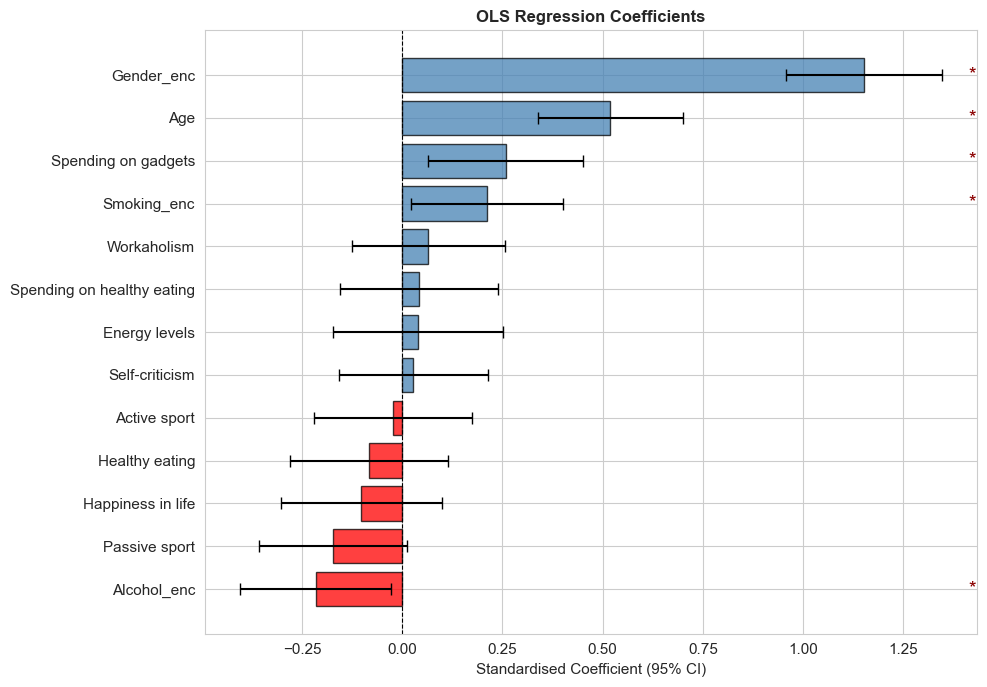

Saved: fig6_ols_coefficients.png


In [13]:
# Figure 6: OLS coefficient plot (standardised betas, excluding intercept)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ols_model.params[1:].values,
    'CI_low': ols_model.conf_int()[0][1:].values,
    'CI_high': ols_model.conf_int()[1][1:].values,
    'p_value': ols_model.pvalues[1:].values
}).sort_values('Coefficient')

colors_coef = ['red' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(coef_df))
ax.barh(y_pos, coef_df['Coefficient'], color=colors_coef, alpha=0.75, edgecolor='black')
ax.errorbar(coef_df['Coefficient'], y_pos,
            xerr=[coef_df['Coefficient'] - coef_df['CI_low'],
                  coef_df['CI_high'] - coef_df['Coefficient']],
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df['Feature'])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Coefficient (95% CI)')
ax.set_title('OLS Regression Coefficients', fontsize=12, fontweight='bold')

# Mark significant predictors
for i, (_, row) in enumerate(coef_df.iterrows()):
    if row['p_value'] < 0.05:
        ax.text(max(coef_df['CI_high']) * 1.05, i, '*', fontsize=14, va='center', color='darkred')

plt.tight_layout()
plt.savefig('fig6_ols_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig6_ols_coefficients.png")

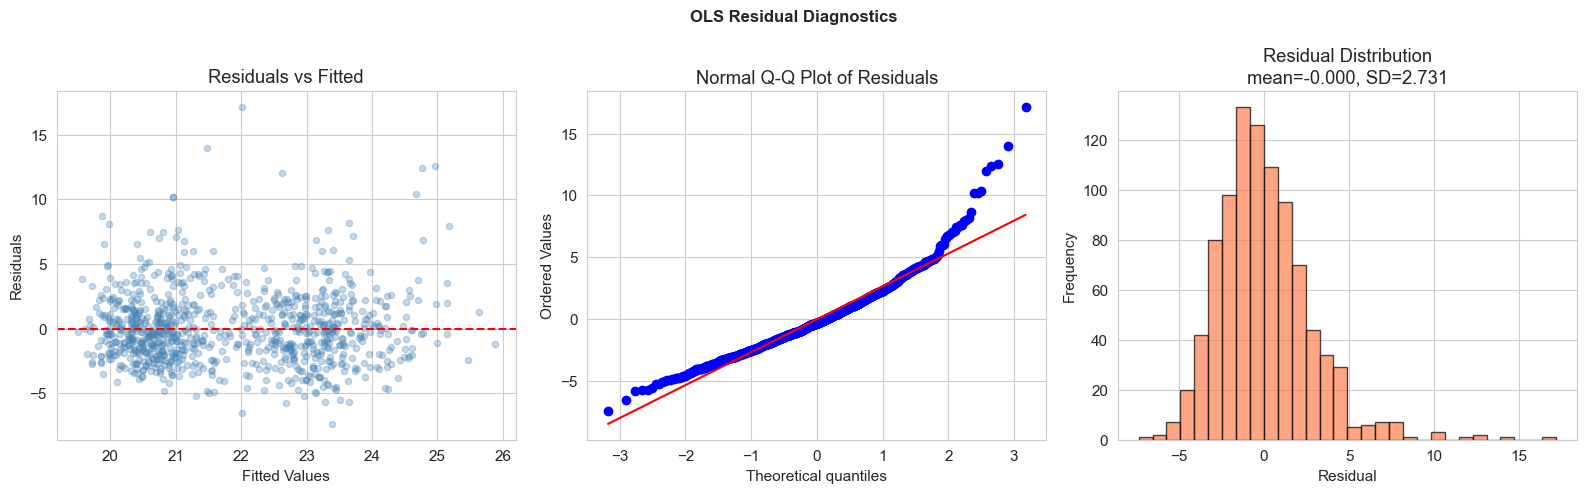

Residual Shapiro-Wilk: W=0.9604, p=0.0000
Saved: fig7_ols_residuals.png


In [14]:
# Figure 7: OLS residual diagnostics
ols_fitted = ols_model.fittedvalues
ols_resid = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Fitted
axes[0].scatter(ols_fitted, ols_resid, alpha=0.3, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot of residuals
probplot(ols_resid, plot=axes[1])
axes[1].set_title('Normal Q-Q Plot of Residuals')

# Residual histogram
axes[2].hist(ols_resid, bins=30, edgecolor='black', color='coral', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Residual Distribution\nmean={ols_resid.mean():.3f}, SD={ols_resid.std():.3f}')

plt.suptitle('OLS Residual Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_ols_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

stat_r, p_r = stats.shapiro(ols_resid.sample(min(500, len(ols_resid)), random_state=42))
print(f"Residual Shapiro-Wilk: W={stat_r:.4f}, p={p_r:.4f}")
print("Saved: fig7_ols_residuals.png")

In [15]:

# Breusch-Pagan test for heteroscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

bp_lm, bp_pval, bp_fval, bp_fpval = het_breuschpagan(ols_resid, ols_model.model.exog)

print("Breusch-Pagan heteroscedasticity test:")
print(f"  LM statistic = {bp_lm:.4f}")
print(f"  LM p-value   = {bp_pval:.4f}")
print(f"  F-statistic  = {bp_fval:.4f}")
print(f"  F p-value    = {bp_fpval:.4f}")

if bp_pval < 0.05:
    print("\n  => Significant heteroscedasticity detected (p < 0.05)")
    print("     OLS standard errors may underestimate true uncertainty.")
else:
    print("\n  => No significant heteroscedasticity (p >= 0.05)")

# HC3-robust standard errors to assess practical impact
ols_robust = ols_model.get_robustcov_results(cov_type='HC3')
robust_bse = pd.Series(ols_robust.bse, index=ols_model.bse.index)

sig_vars = ['Gender_enc', 'Age', 'Spending on gadgets', 'Smoking_enc', 'Alcohol_enc']
labels   = ['Gender',     'Age', 'Spending on gadgets', 'Smoking',     'Alcohol']
print("\nTop 5 predictors: OLS SE vs HC3-robust SE")
print(f"{'Predictor':<30} {'OLS SE':>10} {'HC3 SE':>10} {'Change':>10}")
for var, lbl in zip(sig_vars, labels):
    ols_se = ols_model.bse[var]
    rob_se = robust_bse[var]
    pct = (rob_se - ols_se) / ols_se * 100
    print(f"{lbl:<30} {ols_se:>10.4f} {rob_se:>10.4f} {pct:>+9.1f}%")


Breusch-Pagan heteroscedasticity test:
  LM statistic = 47.7278
  LM p-value   = 0.0000
  F-statistic  = 3.8127
  F p-value    = 0.0000

  => Significant heteroscedasticity detected (p < 0.05)
     OLS standard errors may underestimate true uncertainty.

Top 5 predictors: OLS SE vs HC3-robust SE
Predictor                          OLS SE     HC3 SE     Change
Gender                             0.0988     0.0996      +0.9%
Age                                0.0927     0.1074     +15.9%
Spending on gadgets                0.0983     0.1078      +9.6%
Smoking                            0.0969     0.1073     +10.7%
Alcohol                            0.0962     0.1052      +9.4%


## 6. Model 2 Ridge Regression with Cross-Validated Regularisation

In [ ]:
# Ridge regression  RidgeCV finds the best alpha automatically
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
kf = KFold(n_splits=10, shuffle=True, random_state=42)

ridge_cv = RidgeCV(alphas=alphas, cv=kf, scoring='neg_mean_squared_error')
ridge_cv.fit(X_scaled, y)

best_alpha = ridge_cv.alpha_
print(f"Best alpha (regularisation strength): {best_alpha}")

y_pred_ridge = ridge_cv.predict(X_scaled)
ridge_r2 = r2_score(y, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y, y_pred_ridge))
ridge_mae = mean_absolute_error(y, y_pred_ridge)

print(f"Ridge R²={ridge_r2:.4f}")
print(f"Ridge RMSE={ridge_rmse:.4f}")
print(f"Ridge MAE={ridge_mae:.4f}")

print("\nRidge Coefficients (standardised):")
ridge_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge_Coef': ridge_cv.coef_
}).sort_values('Ridge_Coef', key=abs, ascending=False)
print(ridge_coef_df.to_string(index=False))

Best alpha (regularisation strength): 100.0


Ridge R²=0.2081
Ridge RMSE=2.7328
Ridge MAE=2.0480

Ridge Coefficients (standardised):
                   Feature  Ridge_Coef
                Gender_enc    1.031499
                       Age    0.482737
       Spending on gadgets    0.257660
               Smoking_enc    0.182944
               Alcohol_enc   -0.179253
             Passive sport   -0.144122
         Happiness in life   -0.083522
            Healthy eating   -0.081009
               Workaholism    0.060206
Spending on healthy eating    0.039101
             Energy levels    0.019127
            Self-criticism    0.015547
              Active sport    0.000106


In [17]:
# 10-fold cross-validation comparison: OLS vs Ridge
kf_eval = KFold(n_splits=10, shuffle=True, random_state=42)

# OLS via sklearn LinearRegression for CV
lr = LinearRegression()
cv_r2_ols = cross_val_score(lr, X_scaled, y, cv=kf_eval, scoring='r2')
cv_rmse_ols = np.sqrt(-cross_val_score(lr, X_scaled, y, cv=kf_eval,
                                        scoring='neg_mean_squared_error'))
cv_mae_ols = -cross_val_score(lr, X_scaled, y, cv=kf_eval,
                               scoring='neg_mean_absolute_error')

# Ridge CV
from sklearn.linear_model import Ridge
ridge_fixed = Ridge(alpha=best_alpha)
cv_r2_ridge = cross_val_score(ridge_fixed, X_scaled, y, cv=kf_eval, scoring='r2')
cv_rmse_ridge = np.sqrt(-cross_val_score(ridge_fixed, X_scaled, y, cv=kf_eval,
                                          scoring='neg_mean_squared_error'))
cv_mae_ridge = -cross_val_score(ridge_fixed, X_scaled, y, cv=kf_eval,
                                 scoring='neg_mean_absolute_error')

print("10-fold Cross-Validation Results")
print("=" * 55)
print(f"{'Metric':<20} {'OLS mean (SD)':>18} {'Ridge mean (SD)':>18}")
print("-" * 55)
print(f"{'R²':<20} {cv_r2_ols.mean():.4f} ({cv_r2_ols.std():.4f})  "
      f"  {cv_r2_ridge.mean():.4f} ({cv_r2_ridge.std():.4f})")
print(f"{'RMSE':<20} {cv_rmse_ols.mean():.4f} ({cv_rmse_ols.std():.4f})  "
      f"  {cv_rmse_ridge.mean():.4f} ({cv_rmse_ridge.std():.4f})")
print(f"{'MAE':<20} {cv_mae_ols.mean():.4f} ({cv_mae_ols.std():.4f})  "
      f"  {cv_mae_ridge.mean():.4f} ({cv_mae_ridge.std():.4f})")

# In-sample metrics for OLS (sklearn)
lr.fit(X_scaled, y)
y_pred_ols = lr.predict(X_scaled)
ols_r2_insample = r2_score(y, y_pred_ols)
ols_rmse_insample = np.sqrt(mean_squared_error(y, y_pred_ols))
ols_mae_insample = mean_absolute_error(y, y_pred_ols)
print(f"\nIn-sample OLS: R²={ols_r2_insample:.4f}, RMSE={ols_rmse_insample:.4f}, MAE={ols_mae_insample:.4f}")
print(f"In-sample Ridge: R²={ridge_r2:.4f}, RMSE={ridge_rmse:.4f}, MAE={ridge_mae:.4f}")

10-fold Cross-Validation Results
Metric                    OLS mean (SD)    Ridge mean (SD)
-------------------------------------------------------
R²                   0.1811 (0.0422)    0.1828 (0.0381)
RMSE                 2.7644 (0.2534)    2.7619 (0.2540)
MAE                  2.0734 (0.1184)    2.0750 (0.1167)



In-sample OLS: R²=0.2100, RMSE=2.7296, MAE=2.0427
In-sample Ridge: R²=0.2081, RMSE=2.7328, MAE=2.0480


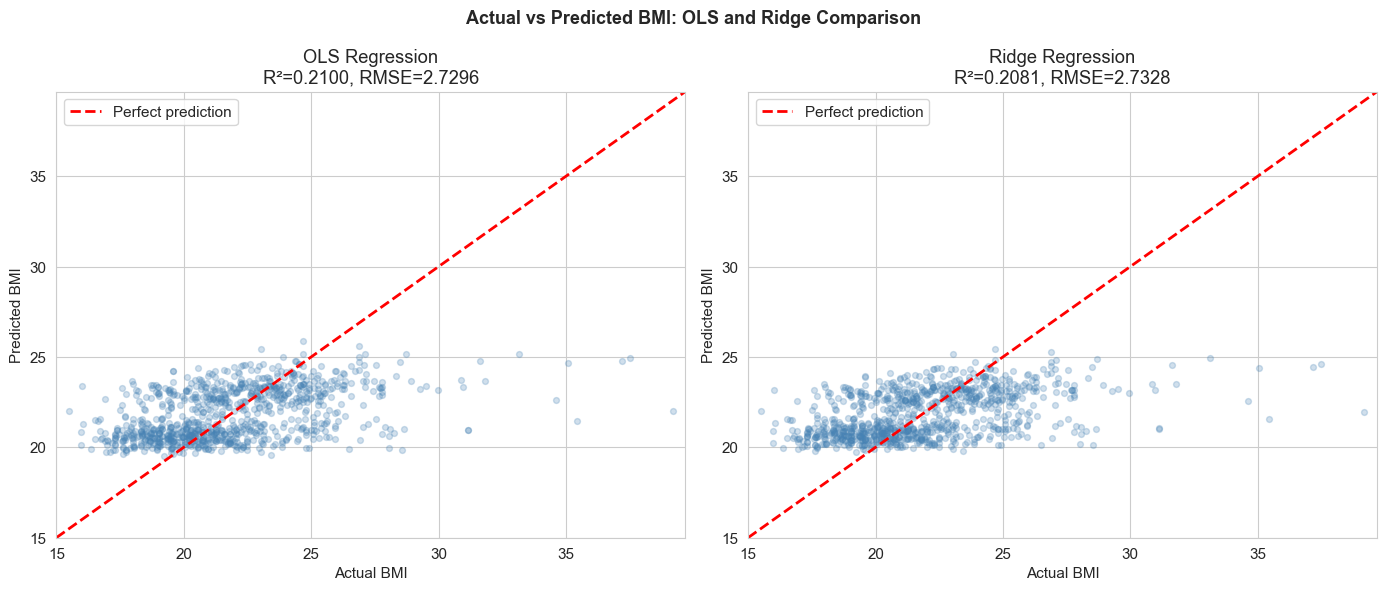

Saved: fig8_model_comparison.png
All figures saved successfully.


In [ ]:
# Figure 8: Model comparison actual vs predicted (OLS and Ridge)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, y_pred, r2_val, rmse_val) in zip(axes, [
    ('OLS', y_pred_ols, ols_r2_insample, ols_rmse_insample),
    ('Ridge', y_pred_ridge, ridge_r2, ridge_rmse)
]):
    ax.scatter(y, y_pred, alpha=0.25, s=18, color='steelblue')
    lims = [min(y.min(), y_pred.min()) - 0.5, max(y.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual BMI')
    ax.set_ylabel('Predicted BMI')
    ax.set_title(f'{label} Regression\nR²={r2_val:.4f}, RMSE={rmse_val:.4f}')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend()

plt.suptitle('Actual vs Predicted BMI: OLS and Ridge Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig8_model_comparison.png")
print("All figures saved successfully.")

In [19]:
from scipy import stats as sp_stats

# Paired fold-by-fold comparison of OLS vs Ridge R^2
# cv_r2_ols and cv_r2_ridge are the 10 per-fold values already computed
fold_diffs = cv_r2_ridge - cv_r2_ols
t_stat, p_val_t = sp_stats.ttest_rel(cv_r2_ridge, cv_r2_ols)

print("Paired fold-by-fold R² comparison: OLS vs Ridge")
print(f"{'Fold':<6} {'OLS R²':>10} {'Ridge R²':>10} {'Δ':>8}")
for i, (o, r) in enumerate(zip(cv_r2_ols, cv_r2_ridge), 1):
    print(f"{i:<6} {o:>10.4f} {r:>10.4f} {r-o:>+8.4f}")
print(f"\nMean Δ = {fold_diffs.mean():+.4f}  (SD = {fold_diffs.std():.4f})")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.3f}")
print(f"Ridge R² SD = {cv_r2_ridge.std():.4f} vs OLS R² SD = {cv_r2_ols.std():.4f}")
print(f"Variance reduction = {(1 - cv_r2_ridge.std()/cv_r2_ols.std())*100:.1f}% smaller SD for Ridge")

Paired fold-by-fold R² comparison: OLS vs Ridge
Fold       OLS R²   Ridge R²        Δ
1          0.1854     0.1860  +0.0006
2          0.1512     0.1533  +0.0022
3          0.2386     0.2355  -0.0032
4          0.2175     0.2173  -0.0002
5          0.1443     0.1523  +0.0080
6          0.1500     0.1619  +0.0119
7          0.1059     0.1093  +0.0034
8          0.2196     0.2155  -0.0041
9          0.2318     0.2244  -0.0074
10         0.1662     0.1721  +0.0059

Mean Δ = +0.0017  (SD = 0.0056)
Paired t-test: t = 0.923, p = 0.380
Ridge R² SD = 0.0381 vs OLS R² SD = 0.0422
Variance reduction = 9.7% smaller SD for Ridge


## 7. Conclusions

This analysis tried to answer whether lifestyle and behavioral habits can predict BMI in young people. After computing BMI from the height and weight columns, filtering out unrealistic values (BMI below 14 or above 50), and removing rows with missing predictor values, the final sample was n=924.

Two regression models were compared using 10-fold cross-validation. OLS got a mean R²=0.181 (SD=0.042) and Ridge got R²=0.183 (SD=0.038). In-sample the OLS model explains R²=0.210 of variance in BMI. This is a modest result, but not surprising given that all predictors are coarse 1-5 self-report scales.

Gender was by far the strongest predictor (standardised coef=1.152, p<0.001). Males on average has about 2.5 more BMI points than females after controlling for everything else. Age is the second strongest (coef=0.519, p<0.001). Spending on gadgets also comes out significant (coef=0.258, p=0.009), which I think reflects sedentary behaviour indirectly. Smoking is positively associated (coef=0.212, p=0.029), which was a bit unexpected. Alcohol is actually negatively associated with BMI (coef=-0.217, p=0.025) people who drink more had slightly lower BMI on average, possibly because of social activity patterns or calorie substitution.

The most notable finding is what does NOT predict BMI: Healthy eating (p=0.409) and Active sport (p=0.818) are both non-significant after gender and age are controlled for. This probably reflect measurement error broad Likert questions cannot capture actual caloric intake or exercise intensity with enough precision.

Ridge regression selects a high regularisation strength (alpha=100), which confirm there is some multicollinearity among predictors. Ridge shrinks the weak predictors (Active sport, Self-criticism, Energy levels) close to zero, which is consistent with what OLS found. I select Ridge as the better model because it is slightly more stable in cross-validation, but both models tell essentially the same story.

Limitations: the sample is limited to young Slovak students, all behavioral variables are self-reported and probably contain social desirability bias, and the non-normal residuals (Shapiro-Wilk W=0.9604, p<0.001) technically violate OLS assumptions. With n=924 this is probably not a big problem in practice, but it should be noted.